<a href="https://colab.research.google.com/github/AnaPRodrigues/postech-ia/blob/main/Classificador_avaliacao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd

avaliacoes = pd.read_csv('b2w.csv')
avaliacoes.head()

,original_index,review_text,review_text_processed,review_text_tokenized,polarity,rating,kfold_polarity,kfold_rating
0,11955,Bem macio e felpudo...recomendo. Preço imbatí...,bem macio e felpudo...recomendo. preco imbati...,"['bem', 'macio', 'felpudo', 'recomendo', 'prec...",1.0,4,1,1
1,35478,Produto excepcional! recomendo!!! inovador e ...,produto excepcional! recomendo!!! inovador e ...,"['produto', 'excepcional', 'recomendo', 'inova...",1.0,5,1,1
2,122760,recebi o produto antes do prazo mas veio com d...,recebi o produto antes do prazo mas veio com d...,"['recebi', 'produto', 'antes', 'do', 'prazo', ...",0.0,1,1,1
3,17114,Bom custo beneficio. Adequado para pessoas que...,bom custo beneficio. adequado para pessoas que...,"['bom', 'custo', 'beneficio', 'adequado', 'par...",1.0,5,1,1
4,19112,Além de higiênico tem o tamanho ideal. Só falt...,alem de higienico tem o tamanho ideal. so falt...,"['alem', 'de', 'higienico', 'tem', 'tamanho', ...",NaN,3,-1,1


In [5]:
avaliacoes = avaliacoes.drop(['original_index', 'review_text_processed', 'review_text_tokenized', 'rating', 'kfold_polarity', 'kfold_rating'], axis = 1)
avaliacoes.head()

,review_text,polarity
0,Bem macio e felpudo...recomendo. Preço imbatí...,1.0
1,Produto excepcional! recomendo!!! inovador e ...,1.0
2,recebi o produto antes do prazo mas veio com d...,0.0
3,Bom custo beneficio. Adequado para pessoas que...,1.0
4,Além de higiênico tem o tamanho ideal. Só falt...,NaN


In [6]:
# Removendo linhas com polatity NaN

avaliacoes.dropna(subset=['polarity'], inplace=True)
avaliacoes.head(10)


,review_text,polarity
0,Bem macio e felpudo...recomendo. Preço imbatí...,1.0
1,Produto excepcional! recomendo!!! inovador e ...,1.0
2,recebi o produto antes do prazo mas veio com d...,0.0
3,Bom custo beneficio. Adequado para pessoas que...,1.0
5,"ótmo produto atendeu as expectativas, a entreg...",1.0
6,"GOSTEI MUITO DO PRODUTO! TEM ÓTIMA QUALIDADE, ...",1.0
7,"Adorei, entrega no prazo e produto conforme eu...",1.0
8,Já é o segundo processador deste modelo que co...,1.0
9,Nao recebi!!! endereço para entrega : rua aug...,1.0
10,"Não compra este produto, pois o mesmo veio com...",0.0


In [7]:
avaliacoes.polarity.value_counts()

,count
polarity,
1.0,80300
0.0,35758


In [8]:
from sklearn.model_selection import train_test_split

x_train, y_train, x_test, y_test = train_test_split(avaliacoes.review_text, avaliacoes.polarity,
                                          stratify=avaliacoes.polarity, random_state=42)

In [ ]:
from sklearn.linear_model import LogisticRegression

# regressao_logistica = LogisticRegression()
# regressao_logistica.fit(x_train, y_train)

ValueError: could not convert string to float: 'Gostei muito do produto! É a segunda vez que comprei e recomento muito....'

In [9]:
from sklearn.feature_extraction.text import CountVectorizer

texto = ['Esse produto é muito bom', 'Esse produto é muito ruim']
vetorizador = CountVectorizer()

bag_of_words = vetorizador.fit_transform(texto)
# matriz esparsa para utilizar muito dados sem usar muita mem´roai
print(bag_of_words)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 8 stored elements and shape (2, 5)>
  Coords	Values
  (0, 1)	1
  (0, 3)	1
  (0, 2)	1
  (0, 0)	1
  (1, 1)	1
  (1, 3)	1
  (1, 2)	1
  (1, 4)	1


In [11]:
# Visualizar o bag of words em um dataframe
matriz_esparsa = pd.DataFrame.sparse.from_spmatrix(bag_of_words, columns=vetorizador.get_feature_names_out())
matriz_esparsa

,bom,esse,muito,produto,ruim
0,1,1,1,1,0
1,0,1,1,1,1


In [13]:
# Contar quantas palavras existem na review (50508 no total)
vetorizar_reviews = CountVectorizer()
bag_of_words_reviews = vetorizar_reviews.fit_transform(avaliacoes.review_text)
print(bag_of_words_reviews)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 2165006 stored elements and shape (116058, 50508)>
  Coords	Values
  (0, 8403)	1
  (0, 30376)	1
  (0, 22622)	1
  (0, 40637)	1
  (0, 38419)	1
  (0, 26332)	1
  (0, 19662)	1
  (0, 42821)	1
  (0, 12335)	1
  (0, 35146)	1
  (0, 39610)	1
  (0, 37987)	1
  (1, 40637)	1
  (1, 38660)	1
  (1, 21562)	1
  (1, 27281)	1
  (1, 24907)	1
  (1, 14760)	1
  (1, 29362)	1
  (2, 38660)	2
  (2, 40426)	1
  (2, 5591)	1
  (2, 17611)	1
  (2, 37934)	1
  (2, 31087)	1
  :	:
  (116056, 18680)	1
  (116056, 17562)	1
  (116056, 5671)	1
  (116056, 48121)	1
  (116056, 4636)	1
  (116056, 37390)	1
  (116057, 38660)	1
  (116057, 14760)	1
  (116057, 40426)	1
  (116057, 34142)	1
  (116057, 39651)	2
  (116057, 33790)	1
  (116057, 23339)	1
  (116057, 46619)	1
  (116057, 12095)	1
  (116057, 44289)	1
  (116057, 48899)	1
  (116057, 19702)	1
  (116057, 28162)	1
  (116057, 41865)	1
  (116057, 40538)	1
  (116057, 27973)	1
  (116057, 47948)	1
  (116057, 13143)	1
  (116057, 7640)

In [14]:
vetorizar_100_mais_palavras = CountVectorizer(max_features=100)
bag_of_words_100_palavras = vetorizar_100_mais_palavras.fit_transform(avaliacoes.review_text)
print(bag_of_words_100_palavras)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 1016607 stored elements and shape (116058, 100)>
  Coords	Values
  (0, 8)	1
  (0, 77)	1
  (0, 70)	1
  (0, 28)	1
  (0, 78)	1
  (0, 74)	1
  (1, 77)	1
  (1, 72)	1
  (1, 21)	1
  (2, 72)	2
  (2, 76)	1
  (2, 3)	1
  (2, 25)	1
  (2, 69)	1
  (2, 44)	1
  (2, 97)	1
  (2, 13)	1
  (2, 52)	1
  (2, 59)	1
  (2, 57)	2
  (2, 19)	1
  (2, 60)	1
  (2, 7)	1
  (2, 0)	1
  (2, 2)	1
  :	:
  (116055, 48)	2
  (116055, 40)	1
  (116055, 68)	1
  (116055, 81)	1
  (116055, 80)	1
  (116056, 72)	1
  (116056, 52)	1
  (116056, 57)	1
  (116056, 75)	1
  (116056, 56)	1
  (116056, 4)	2
  (116056, 83)	1
  (116056, 82)	2
  (116056, 66)	1
  (116057, 72)	1
  (116057, 21)	1
  (116057, 76)	1
  (116057, 57)	1
  (116057, 75)	2
  (116057, 56)	1
  (116057, 37)	1
  (116057, 91)	1
  (116057, 14)	1
  (116057, 83)	1
  (116057, 29)	1


In [20]:
from sklearn.linear_model import LogisticRegression
X_train, X_test, y_train, y_test = train_test_split(bag_of_words_100_palavras, avaliacoes.polarity, stratify=avaliacoes.polarity, random_state=42)

regressao_logistica = LogisticRegression()
regressao_logistica.fit(X_train, y_train)
acucaria = regressao_logistica.score(X_test, y_test)
print(acucaria)

0.8881268309495088


In [21]:
def treinar_modelo(dados, coluna_texto, coluna_sentimento):
  vetorizar_100_mais_palavras = CountVectorizer(max_features=100)
  bag_of_words_100_palavras = vetorizar_100_mais_palavras.fit_transform(avaliacoes.review_text)

  X_train, X_test, y_train, y_test = train_test_split(bag_of_words_100_palavras, avaliacoes.polarity, stratify=avaliacoes.polarity, random_state=42)

  regressao_logistica = LogisticRegression()
  regressao_logistica.fit(X_train, y_train)
  return regressao_logistica.score(X_test, y_test)


In [22]:
print(treinar_modelo(avaliacoes, 'review_text', 'polarity'))

0.8881268309495088


# Word Cloud

Fazendo uma word cloud

In [24]:
from wordcloud import WordCloud

todas_avaliacoes = [texto for texto in avaliacoes.review_text]

todas_palavras = ' '.join(todas_avaliacoes)

len(todas_avaliacoes)

116058

In [25]:
nuvem_palavras = WordCloud().generate(todas_palavras)

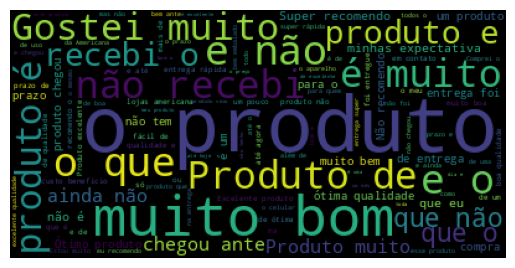

In [33]:
import matplotlib.pyplot as plt

plt.imshow(nuvem_palavras)
plt.axis('off')
plt.show()
#

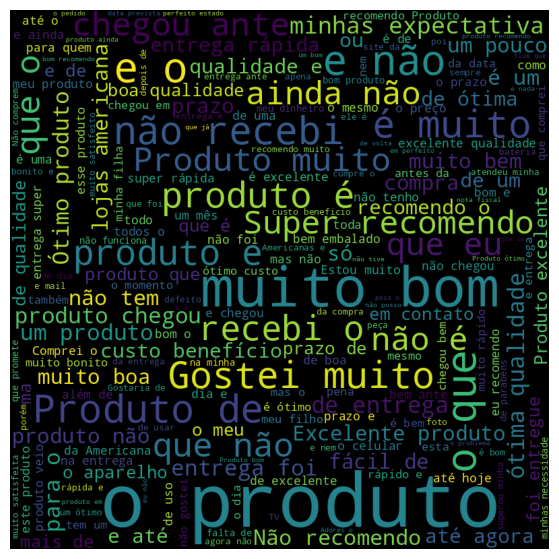

In [36]:
nuvem_palavras = WordCloud(width=800, height=800, max_font_size=110).generate(todas_palavras)

plt.figure(figsize=(10, 7))
plt.imshow(nuvem_palavras)
plt.axis('off')
plt.show()
#

In [42]:
def word_cloud_neg(dados, coluna_texto):
  texto_negativo = dados.query("polarity == 0")

  todas_avaliacoes = [texto for texto in texto_negativo[coluna_texto]]

  todas_palavras = ' '.join(todas_avaliacoes)

  nuvem_palavras = WordCloud(width=800, height=800, max_font_size=110, collocations=False).generate(todas_palavras)

  plt.figure(figsize=(10, 7))
  plt.imshow(nuvem_palavras, interpolation='bilinear')
  plt.axis('off')
  plt.show()


In [45]:
def word_cloud_pos(dados, coluna_texto):
  texto_positivo = dados.query("polarity == 1")

  todas_avaliacoes = [texto for texto in texto_positivo[coluna_texto]]

  todas_palavras = ' '.join(todas_avaliacoes)

  nuvem_palavras = WordCloud(width=800, height=800, max_font_size=110, collocations=False).generate(todas_palavras)

  plt.figure(figsize=(10, 7))
  plt.imshow(nuvem_palavras, interpolation='bilinear')
  plt.axis('off')
  plt.show()


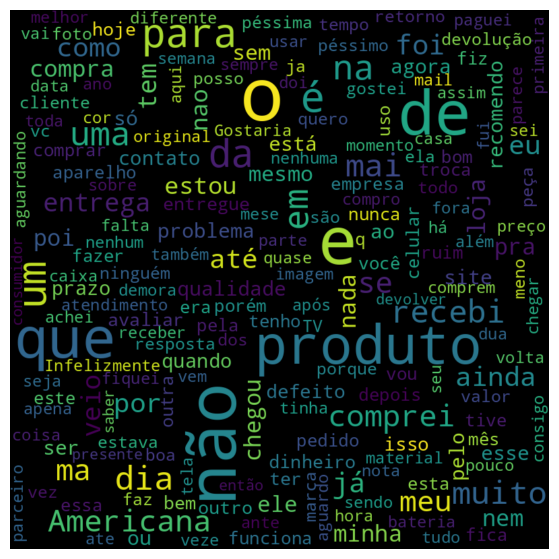

In [43]:
word_cloud_neg(avaliacoes, 'review_text')


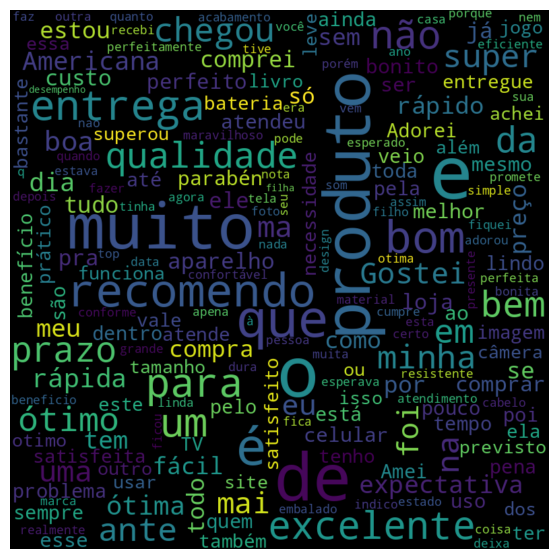

In [46]:
word_cloud_pos(avaliacoes, 'review_text')